# Feature Extraction using ResNet50

This notebook extracts high-level visual features from brain MRI scans using a pretrained ResNet50 model. It processes labeled and unlabeled images separately to prevent data leakage, producing 2048-dimensional feature vectors that serve as input for downstream clustering and classification tasks.

## Table of Contents
1. [Import Required Libraries](#1-import-required-libraries)
2. [Data Exploration](#2-data-exploration)
3. [Data Preparation for Feature Extraction](#3-data-preparation-for-feature-extraction)
4. [Feature Extraction with ResNet50](#4-feature-extraction-with-resnet50)
5. [Analyze Extracted Features](#5-analyze-extracted-features)
6. [Save Extracted Features](#6-save-extracted-features)

## 1. Import Required Libraries

We'll use:
- **PyTorch & torchvision**: Deep learning framework and pretrained models
- **PIL/Pillow**: Image loading and manipulation
- **NumPy**: Numerical operations
- **Pandas**: Data organization
- **Matplotlib**: Visualization

In [1]:
# Standard libraries
import os
import random
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Image processing
from PIL import Image

# Deep learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from tqdm import tqdm

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Device configuration (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


## 2. Data Exploration

### 2.1 Define Data Paths

In [2]:
# Define base paths
DATA_DIR = Path('../data') if not Path('data').exists() and Path('../data').exists() else Path('data')
LABELLED_DIR = DATA_DIR / 'labelled'
UNLABELLED_DIR = DATA_DIR / 'unlabelled'

# Verify directories exist
assert DATA_DIR.exists(), f"Data directory not found: {DATA_DIR}"
assert LABELLED_DIR.exists(), f"Labelled directory not found: {LABELLED_DIR}"
assert UNLABELLED_DIR.exists(), f"Unlabelled directory not found: {UNLABELLED_DIR}"

print("✓ All data directories found successfully")

✓ All data directories found successfully


### 2.2 Count Images by Category

In [3]:
# Count labeled images
cancer_dir = LABELLED_DIR / 'cancer'
normal_dir = LABELLED_DIR / 'normal'

cancer_images = list(cancer_dir.glob('*.jpg'))
normal_images = list(normal_dir.glob('*.jpg'))
unlabelled_images = list(UNLABELLED_DIR.glob('*.jpg'))

# Display counts
print("="*60)
print("DATASET STATISTICS")
print("="*60)
print("\n📊 Labeled Images:")
print(f"   - Cancer:      {len(cancer_images):4d} images")
print(f"   - Normal:      {len(normal_images):4d} images")
print(f"   - Total:       {len(cancer_images) + len(normal_images):4d} images")
print(f"\n📊 Unlabeled Images: {len(unlabelled_images):4d} images")
print(f"\n📊 Grand Total:      {len(cancer_images) + len(normal_images) + len(unlabelled_images):4d} images")
print("="*60)

# Calculate class balance
if len(cancer_images) > 0 and len(normal_images) > 0:
    balance_ratio = len(cancer_images) / len(normal_images)
    print(f"\n⚖️  Class Balance Ratio (Cancer/Normal): {balance_ratio:.2f}")
    if 0.9 <= balance_ratio <= 1.1:
        print("   Status: ✓ Well balanced")
    else:
        print("   Status: ⚠️  Imbalanced - may need class weighting")

DATASET STATISTICS

📊 Labeled Images:
   - Cancer:        50 images
   - Normal:        50 images
   - Total:        100 images

📊 Unlabeled Images: 1406 images

📊 Grand Total:      1506 images

⚖️  Class Balance Ratio (Cancer/Normal): 1.00
   Status: ✓ Well balanced


### 2.3 Inspect Image Properties

Let's verify the image dimensions, color channels, and file sizes.

In [4]:
# Sample random images from each category
sample_images = [
    ('Cancer', random.choice(cancer_images)),
    ('Normal', random.choice(normal_images)),
    ('Unlabelled', random.choice(unlabelled_images))
]

print("\n" + "="*60)
print("IMAGE PROPERTIES")
print("="*60)

for category, img_path in sample_images:
    try:
        img = Image.open(img_path)
        file_size_kb = os.path.getsize(img_path) / 1024

        print(f"\n{category}:")
        print(f"   - Dimensions: {img.size[0]}×{img.size[1]} pixels")
        print(f"   - Mode: {img.mode} ({len(img.getbands())} channels)")
        print(f"   - File size: {file_size_kb:.1f} KB")
        print(f"   - Format: {img.format}")
    except FileNotFoundError:
        print(f"\n{category}: ❌ ERROR - Image file not found: {img_path}")
    except Exception as e:
        print(f"\n{category}: ❌ ERROR - Failed to load image: {e}")


IMAGE PROPERTIES



Cancer:
   - Dimensions: 512×512 pixels
   - Mode: RGB (3 channels)
   - File size: 22.8 KB
   - Format: JPEG



Normal:
   - Dimensions: 512×512 pixels
   - Mode: RGB (3 channels)
   - File size: 54.5 KB
   - Format: JPEG

Unlabelled:
   - Dimensions: 512×512 pixels
   - Mode: RGB (3 channels)
   - File size: 23.4 KB
   - Format: JPEG


### 2.4 Visualize Sample Images

Visual inspection helps us understand:
- Image quality and consistency
- Visible differences between normal and cancerous scans
- Potential preprocessing needs


🧠 CANCER BRAIN SCANS


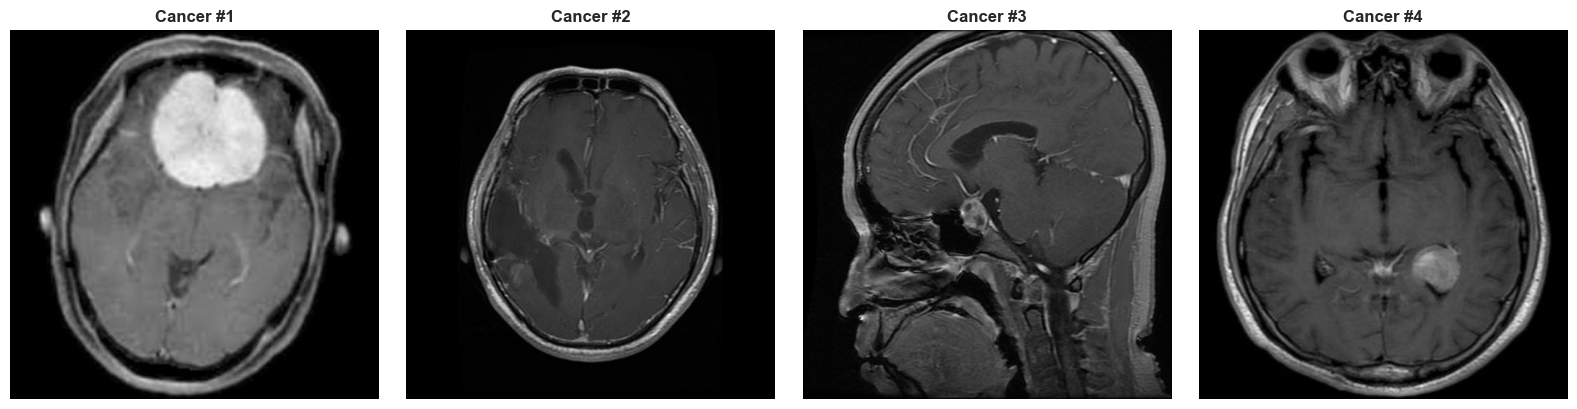


🧠 NORMAL BRAIN SCANS


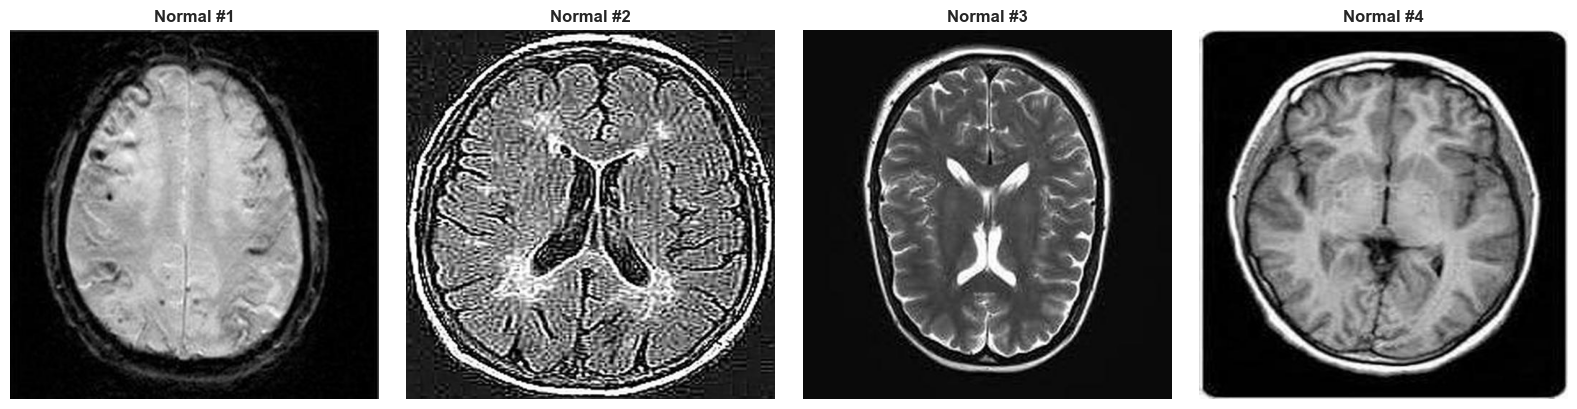


🧠 UNLABELED BRAIN SCANS


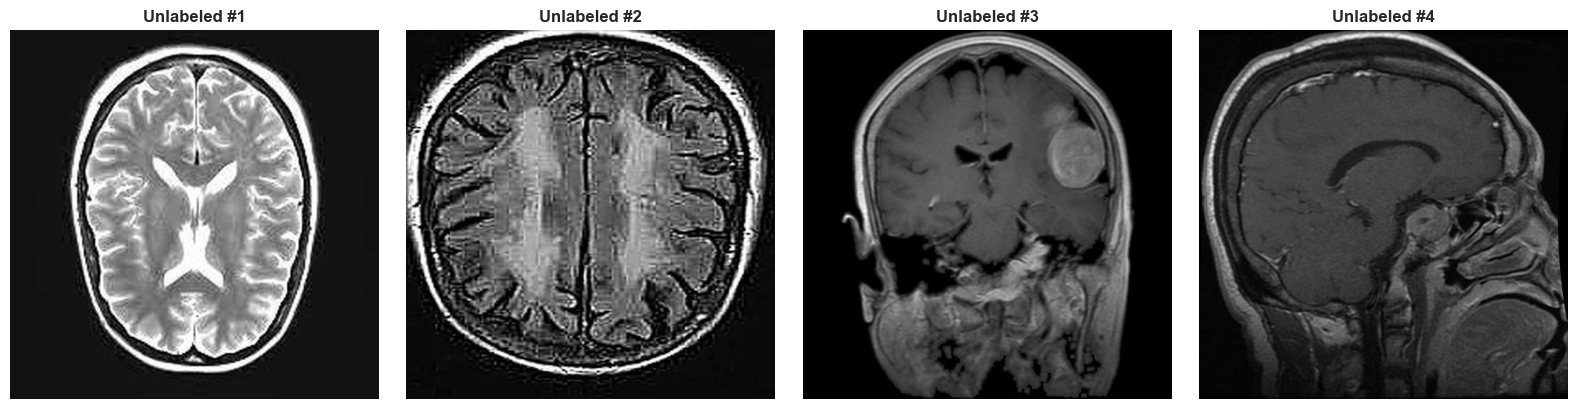

In [5]:
# Function to display a grid of images
def display_image_grid(images, titles, rows=2, cols=4, figsize=(16, 8)):
    """
    Display a grid of images with titles.
    
    Args:
        images: List of image paths or PIL Images
        titles: List of titles for each image
        rows: Number of rows in grid
        cols: Number of columns in grid
        figsize: Figure size (width, height)
    """
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()
    
    for idx, (img_path, title) in enumerate(zip(images, titles)):
        if idx >= len(axes):
            break
        
        # Load image if path provided
        img = Image.open(img_path) if isinstance(img_path, (str, Path)) else img_path
        
        # Display image
        axes[idx].imshow(img, cmap='gray' if img.mode == 'L' else None)
        axes[idx].set_title(title, fontsize=12, fontweight='bold')
        axes[idx].axis('off')
    
    # Hide unused subplots
    for idx in range(len(images), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Sample images for visualization
n_samples = 4
sample_cancer = random.sample(cancer_images, n_samples)
sample_normal = random.sample(normal_images, n_samples)

# Display cancer samples
print("\n🧠 CANCER BRAIN SCANS")
display_image_grid(
    sample_cancer,
    [f"Cancer #{i+1}" for i in range(n_samples)],
    rows=1, cols=4, figsize=(16, 4)
)

# Display normal samples
print("\n🧠 NORMAL BRAIN SCANS")
display_image_grid(
    sample_normal,
    [f"Normal #{i+1}" for i in range(n_samples)],
    rows=1, cols=4, figsize=(16, 4)
)

# Display unlabeled samples
print("\n🧠 UNLABELED BRAIN SCANS")
sample_unlabelled = random.sample(unlabelled_images, n_samples)
display_image_grid(
    sample_unlabelled,
    [f"Unlabeled #{i+1}" for i in range(n_samples)],
    rows=1, cols=4, figsize=(16, 4)
)

## 3. Data Preparation for Feature Extraction

### 3.1 Create Dataset Catalog

We'll create a pandas DataFrame to organize all images with their paths and labels.

In [6]:
# Create lists for DataFrame
image_paths = []
labels = []
label_names = []
data_splits = []

# Add cancer images (label = 1)
for img_path in cancer_images:
    image_paths.append(str(img_path))
    labels.append(1)
    label_names.append('cancer')
    data_splits.append('labeled')

# Add normal images (label = 0)
for img_path in normal_images:
    image_paths.append(str(img_path))
    labels.append(0)
    label_names.append('normal')
    data_splits.append('labeled')

# Add unlabeled images (label = -1)
for img_path in unlabelled_images:
    image_paths.append(str(img_path))
    labels.append(-1)
    label_names.append('unlabeled')
    data_splits.append('unlabeled')

# Create DataFrame
df_images = pd.DataFrame({
    'image_path': image_paths,
    'label': labels,
    'label_name': label_names,
    'split': data_splits,
    'image_id': [Path(p).stem for p in image_paths]
})

# Validate DataFrame
assert len(df_images) > 0, "❌ ERROR: DataFrame is empty - no images found"
assert len(df_images) == 1506, f"❌ ERROR: Expected 1506 images, found {len(df_images)}"
assert df_images['label'].isin([-1, 0, 1]).all(), "❌ ERROR: Invalid label values detected"
assert not df_images.isnull().any().any(), "❌ ERROR: DataFrame contains null values"

print(f"\n📋 Dataset Catalog Created: {len(df_images)} images")
print("✓ Validation passed: All data is valid")
print("\nFirst few entries:")
display(df_images.head(10))

print("\nLast few entries (unlabeled):")
display(df_images.tail(5))

print("\nDataset Summary:")
print(df_images.groupby(['split', 'label_name']).size())


📋 Dataset Catalog Created: 1506 images
✓ Validation passed: All data is valid

First few entries:


,image_path,label,label_name,split,image_id
0,..\data\labelled\cancer\05340cd4-3bb2-459d-993...,1,cancer,labeled,05340cd4-3bb2-459d-9937-bf27d52d8351
1,..\data\labelled\cancer\0c6f3641-60d9-4a76-abe...,1,cancer,labeled,0c6f3641-60d9-4a76-abe5-de89d55d5f2c
2,..\data\labelled\cancer\0f718241-8f63-4b55-81c...,1,cancer,labeled,0f718241-8f63-4b55-81ce-315324b51069
3,..\data\labelled\cancer\11a7a426-4806-401e-98b...,1,cancer,labeled,11a7a426-4806-401e-98b2-b96e7094d1a6
4,..\data\labelled\cancer\1c043dbb-4623-4769-8e5...,1,cancer,labeled,1c043dbb-4623-4769-8e5e-0223bd745040
5,..\data\labelled\cancer\27149ff6-8363-4942-a72...,1,cancer,labeled,27149ff6-8363-4942-a72a-eb7e38e77099
6,..\data\labelled\cancer\2b810835-844c-49ff-b0f...,1,cancer,labeled,2b810835-844c-49ff-b0f1-c7a71a0c696c
7,..\data\labelled\cancer\2d662cc1-509b-4657-a20...,1,cancer,labeled,2d662cc1-509b-4657-a208-6d181aedd5e3
8,..\data\labelled\cancer\2fa551e9-5b85-44f6-ab7...,1,cancer,labeled,2fa551e9-5b85-44f6-ab71-6035b4e3f8aa
9,..\data\labelled\cancer\3c3d07cb-ec2a-43b0-b8a...,1,cancer,labeled,3c3d07cb-ec2a-43b0-b8a3-3a51573ad930



Last few entries (unlabeled):


,image_path,label,label_name,split,image_id
1501,..\data\unlabelled\ff3d5248-a7a7-47f6-8fe4-a44...,-1,unlabeled,unlabeled,ff3d5248-a7a7-47f6-8fe4-a44a45af64f5
1502,..\data\unlabelled\ff93375a-a8ea-4c44-9679-8b6...,-1,unlabeled,unlabeled,ff93375a-a8ea-4c44-9679-8b62ff51b9ef
1503,..\data\unlabelled\ffab85a5-cdb8-4c32-aa75-926...,-1,unlabeled,unlabeled,ffab85a5-cdb8-4c32-aa75-926199136003
1504,..\data\unlabelled\ffae953a-1429-4a56-a258-7c4...,-1,unlabeled,unlabeled,ffae953a-1429-4a56-a258-7c4c0160a117
1505,..\data\unlabelled\ffe6c966-3830-4e88-b02d-bb4...,-1,unlabeled,unlabeled,ffe6c966-3830-4e88-b02d-bb47fdf4da18



Dataset Summary:
split      label_name
labeled    cancer          50
           normal          50
unlabeled  unlabeled     1406
dtype: int64


### 3.2 Define Image Preprocessing Transforms Using Official ResNet50 Preprocessing

**⚠️ IMPORTANT: Using Model's Official Preprocessing**

Instead of manually defining preprocessing transforms, we use the official preprocessing from ResNet50's weights. This approach:

- **Ensures exact match** with the model's training preprocessing
- **Prevents version drift** - if PyTorch updates the model weights, preprocessing automatically updates
- **Eliminates human error** - no risk of typos in mean/std values
- **Follows best practices** - recommended by PyTorch documentation

The official transforms handle:
- Input size: 224×224 pixels
- Normalization with ImageNet mean and std: [0.485, 0.456, 0.406] / [0.229, 0.224, 0.225]
- Proper resize and crop operations

In [7]:
# Load ResNet50 weights and use official preprocessing transforms
# This ensures exact match with training preprocessing
try:
    weights = models.ResNet50_Weights.DEFAULT
    preprocess_transform = weights.transforms()

    print("✓ Using official ResNet50 preprocessing transforms")
    print("  - Automatically matches model's training preprocessing")
    print("  - No risk of version drift or outdated values")
    print(f"  - Transform: {preprocess_transform}")
except Exception as e:
    raise RuntimeError(f"❌ ERROR: Failed to load ResNet50 weights: {e}")

✓ Using official ResNet50 preprocessing transforms
  - Automatically matches model's training preprocessing
  - No risk of version drift or outdated values
  - Transform: ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


### 3.3 Create Custom Dataset Class

In [8]:
class BrainMRIDataset(Dataset):
    """
    Custom PyTorch Dataset for Brain MRI images.
    
    Args:
        dataframe: pandas DataFrame with 'image_path' and 'label' columns
        transform: torchvision transforms to apply to images
    """
    
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        """Return the total number of images."""
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        """
        Load and return a single image and its label.
        
        Returns:
            tuple: (image_tensor, label, image_path)
        """
        # Get image path and label
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['label']
        
        # Load image with error handling
        try:
            image = Image.open(img_path).convert('RGB')  # Ensure 3 channels
        except FileNotFoundError:
            raise FileNotFoundError(f"❌ ERROR: Image not found: {img_path}")
        except Exception as e:
            raise RuntimeError(f"❌ ERROR: Failed to load image {img_path}: {e}")
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        return image, label, img_path

# Create dataset
full_dataset = BrainMRIDataset(df_images, transform=preprocess_transform)

# Validate dataset
assert len(full_dataset) == 1506, f"❌ ERROR: Expected 1506 samples, got {len(full_dataset)}"
sample_img, sample_label, _ = full_dataset[0]
assert sample_img.shape == (3, 224, 224), f"❌ ERROR: Expected shape (3, 224, 224), got {sample_img.shape}"
assert sample_label in [-1, 0, 1], f"❌ ERROR: Invalid label value: {sample_label}"

print(f"\n✓ Dataset created: {len(full_dataset)} images")
print("✓ Validation passed: All samples have correct shape")
print(f"  - Sample batch shape: {sample_img.shape}")
print(f"  - Sample label: {sample_label}")


✓ Dataset created: 1506 images
✓ Validation passed: All samples have correct shape
  - Sample batch shape: torch.Size([3, 224, 224])
  - Sample label: 1


## 4. Feature Extraction with ResNet50

### 4.1 Understanding ResNet50 Architecture

**ResNet50** (Residual Network with 50 layers) is a powerful CNN architecture that:
- Uses skip connections to enable training of very deep networks
- Was pretrained on ImageNet (1.2M images, 1000 classes)
- Achieves state-of-the-art performance on various vision tasks

**Feature Extraction Strategy:**
- We remove the final classification layer (1000 classes)
- Extract features from the penultimate layer (2048 dimensions)
- These features capture high-level visual patterns applicable to our medical images

### 4.2 Load Pretrained ResNet50

In [9]:
# Load pretrained ResNet50 using the same weights as preprocessing
print("Loading ResNet50 pretrained on ImageNet...")
try:
    resnet50 = models.resnet50(weights=weights)

    # Remove the final fully connected layer
    # This gives us 2048-dimensional feature vectors
    feature_extractor = nn.Sequential(*list(resnet50.children())[:-1])

    # Move model to device (GPU if available)
    feature_extractor = feature_extractor.to(device)

    # Set to evaluation mode (disables dropout, batch norm training mode)
    feature_extractor.eval()

    # Freeze all parameters (no gradient computation needed)
    for param in feature_extractor.parameters():
        param.requires_grad = False

    print("\n✓ ResNet50 feature extractor loaded successfully")
    print(f"  - Device: {device}")
    print(f"  - Weights: {weights}")
    print("  - Output feature dimension: 2048")
    print(f"  - Total parameters: {sum(p.numel() for p in feature_extractor.parameters()):,}")
except Exception as e:
    raise RuntimeError(f"❌ ERROR: Failed to load ResNet50 model: {e}")

Loading ResNet50 pretrained on ImageNet...



✓ ResNet50 feature extractor loaded successfully
  - Device: cpu
  - Weights: ResNet50_Weights.IMAGENET1K_V2
  - Output feature dimension: 2048
  - Total parameters: 23,508,032


### 4.3 Split Data BEFORE Feature Extraction (Data Leakage Fix)

**⚠️ CRITICAL: Preventing Data Leakage**

To ensure valid evaluation, we must split the labeled dataset **BEFORE** extracting features.

**Why this matters:**
- ResNet50 uses batch normalization layers
- Batch norm computes mean/std statistics during forward pass
- If we extract features from all images together, test set statistics influence train features
- This creates **data leakage** and artificially inflates performance

**Our approach:**
1. Split 100 labeled images into train/val/test FIRST
2. Extract features separately for each split
3. Also extract features for unlabeled data separately
4. Save split-specific feature files

**Split strategy:**
- Train: 60% (60 images)
- Val: 10% (10 images)
- Test: 30% (30 images)
- Unlabeled: 1,406 images (processed separately)

This ensures complete independence between train/val/test sets during feature extraction.

In [10]:
from sklearn.model_selection import train_test_split

print("="*80)
print("DATA SPLITTING - PREVENTING DATA LEAKAGE")
print("="*80)

# Separate labeled and unlabeled data
labeled_df = df_images[df_images['label'] != -1].copy()
unlabeled_df = df_images[df_images['label'] == -1].copy()

print(f"\nLabeled images: {len(labeled_df)}")
print(f"  - Cancer: {(labeled_df['label'] == 1).sum()}")
print(f"  - Normal: {(labeled_df['label'] == 0).sum()}")
print(f"\nUnlabeled images: {len(unlabeled_df)}")

# Validate before splitting
assert len(labeled_df) == 100, f"❌ ERROR: Expected 100 labeled images, got {len(labeled_df)}"
assert len(unlabeled_df) == 1406, f"❌ ERROR: Expected 1406 unlabeled images, got {len(unlabeled_df)}"

# Split labeled data: 60% train, 10% val, 30% test
# First split: 70% train+val, 30% test
train_val_df, test_df = train_test_split(
    labeled_df,
    test_size=0.30,
    random_state=SEED,
    stratify=labeled_df['label']
)

# Second split: 60% train, 10% val (from the 70%)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.143,  # 0.143 * 70 ≈ 10% of total
    random_state=SEED,
    stratify=train_val_df['label']
)

# Validate splits
assert len(train_df) + len(val_df) + len(test_df) == 100, "❌ ERROR: Split counts don't sum to 100"
assert len(train_df) > 0 and len(val_df) > 0 and len(test_df) > 0, "❌ ERROR: Empty split detected"

print("\n" + "="*80)
print("SPLIT RESULTS")
print("="*80)

print(f"\nTrain set: {len(train_df)} images ({len(train_df)/len(labeled_df)*100:.1f}%)")
print(f"  - Cancer: {(train_df['label'] == 1).sum()}")
print(f"  - Normal: {(train_df['label'] == 0).sum()}")

print(f"\nValidation set: {len(val_df)} images ({len(val_df)/len(labeled_df)*100:.1f}%)")
print(f"  - Cancer: {(val_df['label'] == 1).sum()}")
print(f"  - Normal: {(val_df['label'] == 0).sum()}")

print(f"\nTest set: {len(test_df)} images ({len(test_df)/len(labeled_df)*100:.1f}%)")
print(f"  - Cancer: {(test_df['label'] == 1).sum()}")
print(f"  - Normal: {(test_df['label'] == 0).sum()}")

print(f"\nUnlabeled set: {len(unlabeled_df)} images")

print("\n✓ Data split complete - ready for INDEPENDENT feature extraction")
print("✓ Validation passed: All splits have valid sizes and class balance")

DATA SPLITTING - PREVENTING DATA LEAKAGE

Labeled images: 100
  - Cancer: 50
  - Normal: 50

Unlabeled images: 1406

SPLIT RESULTS

Train set: 59 images (59.0%)
  - Cancer: 30
  - Normal: 29

Validation set: 11 images (11.0%)
  - Cancer: 5
  - Normal: 6

Test set: 30 images (30.0%)
  - Cancer: 15
  - Normal: 15

Unlabeled set: 1406 images

✓ Data split complete - ready for INDEPENDENT feature extraction
✓ Validation passed: All splits have valid sizes and class balance


### 4.4 Extract Features Separately for Each Split

Now we'll extract features independently for each split:
1. Train features (60 images)
2. Validation features (10 images)
3. Test features (30 images)
4. Unlabeled features (1,406 images)

This ensures batch normalization statistics are computed independently for each split.

In [11]:
def extract_features_from_df(model, dataframe, transform, device, batch_size=32, desc="Extracting"):
    """
    Extract features from images in a DataFrame.
    
    Args:
        model: Feature extraction model
        dataframe: DataFrame with 'image_path' and 'label' columns
        transform: Image preprocessing transforms
        device: Device to run inference on
        batch_size: Batch size for DataLoader
        desc: Description for progress bar
    
    Returns:
        tuple: (features_array, labels_array, image_paths_list)
    """
    # Create dataset and dataloader for this split
    dataset = BrainMRIDataset(dataframe, transform=transform)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    all_features = []
    all_labels = []
    all_paths = []
    
    model.eval()
    
    with torch.no_grad():
        for images, labels, paths in tqdm(dataloader, desc=desc):
            # Move images to device
            images = images.to(device)
            
            # Extract features
            features = model(images)
            
            # Reshape: (batch_size, 2048, 1, 1) -> (batch_size, 2048)
            features = features.squeeze(-1).squeeze(-1)
            
            # Move to CPU and convert to numpy
            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())
            all_paths.extend(paths)
    
    # Concatenate all batches
    features_array = np.vstack(all_features)
    labels_array = np.hstack(all_labels)
    
    return features_array, labels_array, all_paths

print("="*80)
print("EXTRACTING FEATURES - SPLIT-BY-SPLIT (NO LEAKAGE)")
print("="*80)

BATCH_SIZE = 32

# Extract features for each split separately
print("\n1️⃣ Extracting TRAIN features...")
train_features, train_labels, train_paths = extract_features_from_df(
    feature_extractor, train_df, preprocess_transform, device, BATCH_SIZE, "Train"
)
print(f"   ✓ Train features: {train_features.shape}")

print("\n2️⃣ Extracting VALIDATION features...")
val_features, val_labels, val_paths = extract_features_from_df(
    feature_extractor, val_df, preprocess_transform, device, BATCH_SIZE, "Validation"
)
print(f"   ✓ Validation features: {val_features.shape}")

print("\n3️⃣ Extracting TEST features...")
test_features, test_labels, test_paths = extract_features_from_df(
    feature_extractor, test_df, preprocess_transform, device, BATCH_SIZE, "Test"
)
print(f"   ✓ Test features: {test_features.shape}")

print("\n4️⃣ Extracting UNLABELED features...")
unlabeled_features, unlabeled_labels, unlabeled_paths = extract_features_from_df(
    feature_extractor, unlabeled_df, preprocess_transform, device, BATCH_SIZE, "Unlabeled"
)
print(f"   ✓ Unlabeled features: {unlabeled_features.shape}")

print("\n" + "="*80)
print("FEATURE EXTRACTION COMPLETE - ALL SPLITS INDEPENDENT")
print("="*80)
print(f"\nTotal features extracted: {train_features.shape[0] + val_features.shape[0] + test_features.shape[0] + unlabeled_features.shape[0]}")
print(f"  - Train:     {train_features.shape[0]:4d} images")
print(f"  - Val:       {val_features.shape[0]:4d} images")
print(f"  - Test:      {test_features.shape[0]:4d} images")
print(f"  - Unlabeled: {unlabeled_features.shape[0]:4d} images")
print("\n✓ No data leakage - each split processed independently")

EXTRACTING FEATURES - SPLIT-BY-SPLIT (NO LEAKAGE)

1️⃣ Extracting TRAIN features...


Train:   0%|                                                                                            | 0/2 [00:00<?, ?it/s]

Train:  50%|██████████████████████████████████████████                                          | 1/2 [00:04<00:04,  4.41s/it]

Train: 100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:07<00:00,  3.58s/it]

Train: 100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:07<00:00,  3.71s/it]

...

Unlabeled:  95%|██████████████████████████████████████████████████████████████████████████▍   | 42/44 [02:32<00:07,  3.77s/it]

Unlabeled:  98%|████████████████████████████████████████████████████████████████████████████▏ | 43/44 [02:36<00:03,  3.64s/it]

Unlabeled: 100%|██████████████████████████████████████████████████████████████████████████████| 44/44 [02:39<00:00,  3.49s/it]

Unlabeled: 100%|██████████████████████████████████████████████████████████████████████████████| 44/44 [02:39<00:00,  3.62s/it]

   ✓ Unlabeled features: (1406, 2048)

FEATURE EXTRACTION COMPLETE - ALL SPLITS INDEPENDENT

Total features extracted: 1506
  - Train:       59 images
  - Val:         11 images
  - Test:        30 images
  - Unlabeled: 1406 images

✓ No data leakage - each split processed independently


### 4.5 Analyze Extracted Features

FEATURE STATISTICS (ALL SPLITS COMBINED)

Feature Array:
  - Shape:  (1506, 2048)
  - Mean:   0.1007
  - Std:    0.3043
  - Min:    0.0000
  - Max:    8.1477

Data Quality:
  - NaN values: 0
  - Inf values: 0
  - Status: ✓ All features are valid


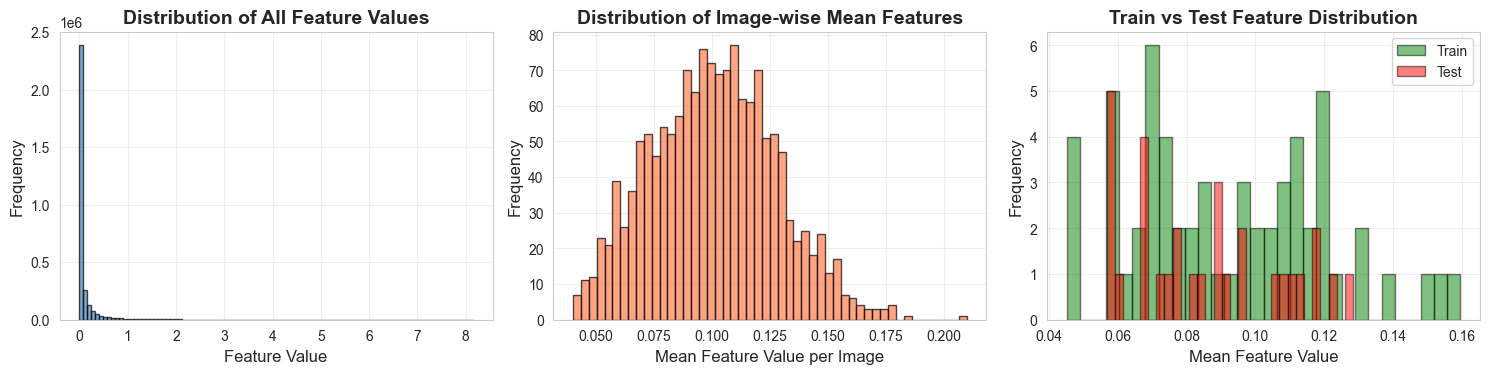

In [12]:
# Combine all features for overall statistics
all_features = np.vstack([train_features, val_features, test_features, unlabeled_features])
all_labels = np.hstack([train_labels, val_labels, test_labels, unlabeled_labels])

print("="*80)
print("FEATURE STATISTICS (ALL SPLITS COMBINED)")
print("="*80)

print("\nFeature Array:")
print(f"  - Shape:  {all_features.shape}")
print(f"  - Mean:   {all_features.mean():.4f}")
print(f"  - Std:    {all_features.std():.4f}")
print(f"  - Min:    {all_features.min():.4f}")
print(f"  - Max:    {all_features.max():.4f}")

# Check for any NaN or Inf values
nan_count = np.isnan(all_features).sum()
inf_count = np.isinf(all_features).sum()

print("\nData Quality:")
print(f"  - NaN values: {nan_count}")
print(f"  - Inf values: {inf_count}")

if nan_count == 0 and inf_count == 0:
    print("  - Status: ✓ All features are valid")
else:
    print("  - Status: ⚠️  Warning: Invalid values detected")

# Visualize feature distribution
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(all_features.flatten(), bins=100, alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('Feature Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of All Feature Values', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
feature_means = all_features.mean(axis=1)
plt.hist(feature_means, bins=50, alpha=0.7, color='coral', edgecolor='black')
plt.xlabel('Mean Feature Value per Image', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Image-wise Mean Features', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
# Compare feature distributions across splits
train_means = train_features.mean(axis=1)
test_means = test_features.mean(axis=1)
plt.hist(train_means, bins=30, alpha=0.5, color='green', label='Train', edgecolor='black')
plt.hist(test_means, bins=30, alpha=0.5, color='red', label='Test', edgecolor='black')
plt.xlabel('Mean Feature Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Train vs Test Feature Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Save Extracted Features (Split-Specific Files)

We'll save features separately for each split to maintain independence.

In [13]:
# Create output directory
OUTPUT_DIR = Path('features')
OUTPUT_DIR.mkdir(exist_ok=True)

print("="*80)
print("SAVING FEATURES - SPLIT-SPECIFIC FILES")
print("="*80)

try:
    # Save train features
    np.save(OUTPUT_DIR / 'train_features.npy', train_features)
    np.save(OUTPUT_DIR / 'train_labels.npy', train_labels)
    train_metadata = pd.DataFrame({
        'image_path': train_paths,
        'label': train_labels,
        'split': ['train'] * len(train_labels),
        'image_id': [Path(p).stem for p in train_paths]
    })
    train_metadata.to_csv(OUTPUT_DIR / 'train_metadata.csv', index=False)
    print(f"\n✓ Train files saved ({len(train_labels)} images)")

    # Save validation features
    np.save(OUTPUT_DIR / 'val_features.npy', val_features)
    np.save(OUTPUT_DIR / 'val_labels.npy', val_labels)
    val_metadata = pd.DataFrame({
        'image_path': val_paths,
        'label': val_labels,
        'split': ['val'] * len(val_labels),
        'image_id': [Path(p).stem for p in val_paths]
    })
    val_metadata.to_csv(OUTPUT_DIR / 'val_metadata.csv', index=False)
    print(f"✓ Validation files saved ({len(val_labels)} images)")

    # Save test features
    np.save(OUTPUT_DIR / 'test_features.npy', test_features)
    np.save(OUTPUT_DIR / 'test_labels.npy', test_labels)
    test_metadata = pd.DataFrame({
        'image_path': test_paths,
        'label': test_labels,
        'split': ['test'] * len(test_labels),
        'image_id': [Path(p).stem for p in test_paths]
    })
    test_metadata.to_csv(OUTPUT_DIR / 'test_metadata.csv', index=False)
    print(f"✓ Test files saved ({len(test_labels)} images)")

    # Save unlabeled features
    np.save(OUTPUT_DIR / 'unlabeled_features.npy', unlabeled_features)
    np.save(OUTPUT_DIR / 'unlabeled_labels.npy', unlabeled_labels)
    unlabeled_metadata = pd.DataFrame({
        'image_path': unlabeled_paths,
        'label': unlabeled_labels,
        'split': ['unlabeled'] * len(unlabeled_labels),
        'image_id': [Path(p).stem for p in unlabeled_paths]
    })
    unlabeled_metadata.to_csv(OUTPUT_DIR / 'unlabeled_metadata.csv', index=False)
    print(f"✓ Unlabeled files saved ({len(unlabeled_labels)} images)")

    # Also save combined versions for backward compatibility with Notebook 2
    all_paths_combined = train_paths + val_paths + test_paths + unlabeled_paths
    np.save(OUTPUT_DIR / 'resnet50_features.npy', all_features)
    np.save(OUTPUT_DIR / 'labels.npy', all_labels)
    combined_metadata = pd.concat([train_metadata, val_metadata, test_metadata, unlabeled_metadata], ignore_index=True)
    combined_metadata.to_csv(OUTPUT_DIR / 'metadata.csv', index=False)
    print("\n✓ Combined files saved (backward compatibility)")

    print("\n" + "="*80)
    print("ALL FILES SAVED SUCCESSFULLY")
    print("="*80)
    print(f"\nOutput directory: {OUTPUT_DIR.absolute()}")
    print("\nSplit-specific files:")
    for split in ['train', 'val', 'test', 'unlabeled']:
        print(f"\n  {split.capitalize()}:")
        print(f"    - {split}_features.npy")
        print(f"    - {split}_labels.npy")
        print(f"    - {split}_metadata.csv")

    print("\nCombined files (for Notebook 2):")
    print("  - resnet50_features.npy")
    print("  - labels.npy")
    print("  - metadata.csv")

    print("\n💡 Split information is preserved in metadata 'split' column")
    
except PermissionError as e:
    raise PermissionError(f"❌ ERROR: Permission denied when saving files: {e}")
except OSError as e:
    raise OSError(f"❌ ERROR: Failed to save files: {e}")
except Exception as e:
    raise RuntimeError(f"❌ ERROR: Unexpected error during file saving: {e}")

SAVING FEATURES - SPLIT-SPECIFIC FILES

✓ Train files saved (59 images)
✓ Validation files saved (11 images)
✓ Test files saved (30 images)
✓ Unlabeled files saved (1406 images)

✓ Combined files saved (backward compatibility)

ALL FILES SAVED SUCCESSFULLY

Output directory: C:\Users\shahu\Documents\OneDrive\OPEN CLASSROOMS\PROJET 7\Medical Images - Cancer\notebooks\features

Split-specific files:

  Train:
    - train_features.npy
    - train_labels.npy
    - train_metadata.csv

  Val:
    - val_features.npy
    - val_labels.npy
    - val_metadata.csv

  Test:
    - test_features.npy
    - test_labels.npy
    - test_metadata.csv

  Unlabeled:
    - unlabeled_features.npy
    - unlabeled_labels.npy
    - unlabeled_metadata.csv

Combined files (for Notebook 2):
  - resnet50_features.npy
  - labels.npy
  - metadata.csv

💡 Split information is preserved in metadata 'split' column
